# Task 1 - Idiom Detection

## Objective
This notebook builds a benchmark for **idiom detection** using the final IdiomX dataset loaded from Hugging Face.

The task is formulated as a **binary classification problem**:

- **idiomatic** usage
- **literal** usage

Given a contextual sentence containing an idiomatic surface form, the model predicts whether the expression is used figuratively or literally.


## Models evaluated
This notebook compares two model families:

1. **Baseline model**
   - TF-IDF + Logistic Regression

2. **Best contextual model**
   - `roberta-base` fine-tuned for binary classification

## Main evaluation outputs
We will report:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- ROC curve and AUC
- Precision–Recall curve
- Confidence analysis
- Calibration analysis
- Qualitative error examples

## Input fields
The main text input will be the cleaned **`example`** field from IdiomX.

The target label will be derived from:
- `example_usage_label`

Useful metadata for analysis may include:
- `idiom_id`
- `idiom_canonical`
- `idiom_surface`
- `minimal_pair_id`
- `context_type`
- `source_style`

## Split philosophy
The main experiment will use a **leakage-aware split** that keeps paired examples together and avoids duplicated-context leakage, while still allowing the same idiom to appear across splits in different contexts.

This choice matches the true goal of Task 1:
**detecting idiomatic vs literal usage in context**, rather than testing unseen idioms only.

## Expected outcome
By the end of this notebook, we will have:

- a reproducible Task 1 benchmark
- a strong lexical baseline
- a fine-tuned transformer model
- publication-ready figures and tables
- material ready to transfer into the research paper

In [2]:
# [0.1] code setup

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

# Create folders for artifacts produced by the notebook
ROOT_DIR = Path(".")
ARTIFACT_DIR = ROOT_DIR / "task1_artifacts"
FIG_DIR = ARTIFACT_DIR / "figures"
MODEL_DIR = ARTIFACT_DIR / "models"
TABLE_DIR = ARTIFACT_DIR / "tables"

for folder in [ARTIFACT_DIR, FIG_DIR, MODEL_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Seed set to:", SEED)
print("Artifacts will be saved under:", ARTIFACT_DIR.resolve())

Seed set to: 42
Artifacts will be saved under: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\notebooks\task1_artifacts


In [3]:
# [0.2] install / check main packages
# If needed, uncomment this line:
# !pip install -q datasets transformers evaluate scikit-learn matplotlib seaborn accelerate sentencepiece

import datasets
import sklearn
import matplotlib
import transformers

print("datasets:", datasets.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("transformers:", transformers.__version__)

datasets: 4.8.4
scikit-learn: 1.8.0
matplotlib: 3.10.8
transformers: 4.41.2


In [5]:
# [1.1] Dataset Load (Hugging Face)
# =================================

from datasets import load_dataset

# Dataset name on Hugging Face
HF_DATASET_NAME = "aymansharara/IdiomX"

# IMPORTANT: specify config name (fix for your error)
CONFIG_NAME = "idiomx"   # full dataset

# Load dataset
dataset = load_dataset(HF_DATASET_NAME, CONFIG_NAME)

# Show available splits
print("Available splits:", list(dataset.keys()))
dataset

Generating idiomx_test split: 100%|███████████████████████████████████| 36008/36008 [00:00<00:00, 137006.19 examples/s]


Available splits: ['idiomx_train', 'idiomx_test']


DatasetDict({
    idiomx_train: Dataset({
        features: ['idiom_id', 'idiom_canonical', 'example', 'example_usage_label', 'idiom_canonical_meaning', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'example_raw', 'example_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'idiom_surface', 'pos', 'tags', 'idiom_confidence', 'is_example_idiom', 'is_generated_example', 'is_adversarial_example', 'meaning_language', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_in_example_arabic', 'enrichment_model', 'enrichment_version', 'validation_status', 'context_type', 'source_style', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'explanation_en', 'explanation_ar', 'minimal_pair_id', 'paraphrase_group_id', 'adversarial_type', 'expected_label', 'row

In [6]:
# [1.2] Convert to Pandas + Basic Exploration
# ===========================================

import pandas as pd

# Convert splits to pandas
df_train = dataset["idiomx_train"].to_pandas()
df_test = dataset["idiomx_test"].to_pandas()

# Combine (for full exploration only — NOT for training yet)
df = pd.concat([df_train, df_test], ignore_index=True)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)
print("Full shape :", df.shape)

# Show columns
print("\nColumns:\n", df.columns.tolist())

# Preview data
df.head(3)

Train shape: (143825, 52)
Test shape : (36008, 52)
Full shape : (179833, 52)

Columns:
 ['idiom_id', 'idiom_canonical', 'example', 'example_usage_label', 'idiom_canonical_meaning', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'example_raw', 'example_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'idiom_surface', 'pos', 'tags', 'idiom_confidence', 'is_example_idiom', 'is_generated_example', 'is_adversarial_example', 'meaning_language', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_in_example_arabic', 'enrichment_model', 'enrichment_version', 'validation_status', 'context_type', 'source_style', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'explanation_en', 'explanation_ar', 'minimal_pair_id', 'paraphrase_group_id', 'adversarial_t

,idiom_id,idiom_canonical,example,example_usage_label,idiom_canonical_meaning,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,example_raw,example_language,source,...,minimal_pair_id,paraphrase_group_id,adversarial_type,expected_label,row_type,example_normalized,sentence_length_chars,sentence_length_words,semantic_similarity_example_vs_meaning,semantic_quality
0,idiomx_543ff4605a0e,'ark at 'ee,Can you 'ark at 'ee to check if the noise is c...,literal,An exclamation used to draw attention to what ...,Literal meaning: physically look at the ear ar...,المعنى الحرفي: النظر إلى منطقة الأذن للتحقق من...,‘Look at that water! No wonder Duddle said he ...,en,kaikki_wiktionary,...,pair_54ada92cc99f,paraphrase_6a8ebd5786f7,None,literal,main_example,can you ark at ee to check if the noise is com...,68,15,0.288639,medium
1,idiomx_543ff4605a0e,'ark at 'ee,"As the storm worsened, Togget shouted, ‘’Ark a...",idiomatic,An exclamation used to draw attention to what ...,"Calling attention to the sound, expressing ala...",لجذب الانتباه إلى الصوت، والتعبير عن القلق أو ...,‘Look at that water! No wonder Duddle said he ...,en,kaikki_wiktionary,...,pair_800639b59519,paraphrase_6a8ebd5786f7,None,idiomatic,main_example,as the storm worsened togget shouted ark at ee...,83,14,0.257582,medium
2,idiomx_543ff4605a0e,'ark at 'ee,"The owl turned its head sharply, and the boy s...",literal,An exclamation used to draw attention to what ...,Literal description of physically looking near...,وصف حرفي للنظر بالقرب من الأذن لسماع الأجنحة.,‘Look at that water! No wonder Duddle said he ...,en,kaikki_wiktionary,...,pair_800639b59519,paraphrase_6a8ebd5786f7,None,literal,main_example,the owl turned its head sharply and the boy sa...,90,18,0.369629,high


## [1.3] Target Definition and Label Analysis

The dataset provides multiple label-related fields:
- `example_usage_label` (candidate target)
- `is_idiom` (binary signal)
- `expected_label` (aligned with usage label)

In [8]:
# [1.3] Target Analysis & Label Validation
# ========================================

# 1. Distribution (main target)
label_counts = df["example_usage_label"].value_counts()
label_percent = df["example_usage_label"].value_counts(normalize=True) * 100

print("Label Distribution:\n")
display(pd.DataFrame({
    "Count": label_counts,
    "Percentage (%)": label_percent.round(2)
}))

# 2. Consistency check
print("\nConsistency (example_usage_label vs is_idiom):\n")
display(pd.crosstab(df["example_usage_label"], df["is_idiom"]))

Label Distribution:



,Count,Percentage (%)
example_usage_label,,
literal,84374,46.92
idiomatic,81905,45.55
borderline,13554,7.54



Consistency (example_usage_label vs is_idiom):



is_idiom,False,True
example_usage_label,,
borderline,575,12979
idiomatic,3041,78864
literal,4111,80263


### Key Observations

- The dataset is **well-balanced** between:
  - Literal (~46.9%)
  - Idiomatic (~45.5%)
  - Borderline (~7.5%)

- The presence of a **borderline class** introduces realistic ambiguity, making the task more challenging and closer to real-world language understanding.

- The `expected_label` field is fully aligned with `example_usage_label`, confirming label consistency.

- However, the `is_idiom` field related to the idiom_canonical column, not aplicable here

### Final Decision

For Task 1 (Idiom Detection), we define:

- **Input:** `example`
- **Target:** `example_usage_label`

We frame this as a **multi-class classification problem**:
- literal
- idiomatic
- borderline

In this experiments, we will evaluate a simplified binary setting by removing the borderline class.

## [1.4] Data Cleaning: Binary Classification Setup

Removing the *borderline* class to focus on a clear binary classification problem:
- literal
- idiomatic

In [10]:
# [1.4] Remove borderline class
# =============================

# Filter dataset
df_binary = df[df["example_usage_label"].isin(["literal", "idiomatic"])].copy()

# Reset index
df_binary = df_binary.reset_index(drop=True)

# Show distribution
label_counts = df_binary["example_usage_label"].value_counts()
label_percent = df_binary["example_usage_label"].value_counts(normalize=True) * 100

print("Binary Label Distribution:\n")
display(pd.DataFrame({
    "Count": label_counts,
    "Percentage (%)": label_percent.round(2)
}))

print("\nDataset shape:", df_binary.shape)

Binary Label Distribution:



,Count,Percentage (%)
example_usage_label,,
literal,84374,50.74
idiomatic,81905,49.26



Dataset shape: (166279, 52)


### Observations After Filtering

- The dataset is **well-balanced**:
  - Literal: 50.74%
  - Idiomatic: 49.26%

- This near-perfect balance ensures:
  - No class imbalance bias
  - Reliable evaluation metrics (accuracy, F1-score)

- The dataset remains large after filtering, providing strong statistical support for training deep learning models.

### Final Task Setup

- **Input:** `example`
- **Target:** `example_usage_label` (binary: literal vs idiomatic)

This configuration is suitable for training robust classification models and aligns with standard idiom detection benchmarks.

## [1.5] Data Leakage Analysis

To ensure a fair evaluation, we must verify that the same idioms do not appear in both training and test sets.

If the same idiom appears in both splits, the model may memorize idioms rather than generalize.

We analyze overlap based on:
- `idiom_id`
- `idiom_canonical`

In [11]:
# [1.5] Leakage Check (idiom overlap)
# ===================================

# Unique idioms per split
train_idioms = set(df_train["idiom_id"])
test_idioms = set(df_test["idiom_id"])

# Overlap
overlap = train_idioms.intersection(test_idioms)

print("Train idioms:", len(train_idioms))
print("Test idioms :", len(test_idioms))
print("Overlap     :", len(overlap))

print("\nOverlap percentage (from test):",
      round(len(overlap) / len(test_idioms) * 100, 2), "%")

Train idioms: 12835
Test idioms : 12020
Overlap     : 12002

Overlap percentage (from test): 99.85 %


## [1.6] Split Strategy and Leakage Resolution

The initial dataset split shows extremely high idiom overlap (~99.85%) between train and test sets.

This indicates that the same idioms appear in both splits, which introduces **data leakage**.

### Why is this a problem?

If the model sees the same idiom during training and testing:
- It may memorize idioms rather than understand context
- Evaluation results become overly optimistic

### Solution: Group-Aware Splitting

To ensure fair evaluation, we enforce:

> All examples of a given idiom (`idiom_id`) must belong to only one split.

This ensures the model is evaluated on **unseen idioms**, testing true generalization.

In [12]:
# [1.6] Group-aware split (by idiom_id)
# =====================================

from sklearn.model_selection import train_test_split

# Get unique idioms
unique_idioms = df_binary["idiom_id"].unique()

# Split idioms (not rows!)
train_ids, temp_ids = train_test_split(
    unique_idioms,
    test_size=0.2,
    random_state=42
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.5,
    random_state=42
)

# Create splits
train_df = df_binary[df_binary["idiom_id"].isin(train_ids)]
val_df   = df_binary[df_binary["idiom_id"].isin(val_ids)]
test_df  = df_binary[df_binary["idiom_id"].isin(test_ids)]

# Print shapes
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (133082, 52)
Validation: (16606, 52)
Test: (16591, 52)


## [1.7] Verification of Leakage Removal

After applying group-aware splitting, we verify that no idiom appears in more than one split.

This confirms that the model will be evaluated on **unseen idioms**, ensuring a fair and realistic evaluation.

In [13]:
# [1.7] Verify NO overlap between splits
# ======================================

train_ids_set = set(train_df["idiom_id"])
val_ids_set   = set(val_df["idiom_id"])
test_ids_set  = set(test_df["idiom_id"])

# Check overlaps
train_val_overlap = train_ids_set.intersection(val_ids_set)
train_test_overlap = train_ids_set.intersection(test_ids_set)
val_test_overlap = val_ids_set.intersection(test_ids_set)

print("Train ∩ Validation:", len(train_val_overlap))
print("Train ∩ Test      :", len(train_test_overlap))
print("Validation ∩ Test :", len(val_test_overlap))

Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0


### Verification Results

- Train ∩ Validation = 0  
- Train ∩ Test = 0  
- Validation ∩ Test = 0  

This confirms that:

- No idiom appears in more than one split
- The dataset is fully **leakage-free**

### Importance

This ensures that the model is evaluated on **unseen idioms**, requiring true generalization rather than memorization.

Such a setup provides a more realistic and challenging benchmark for idiom detection.

### Final Split Strategy

- Train: 80% of idioms  
- Validation: 10% of idioms  
- Test: 10% of idioms  

This split is performed at the **idiom level**, not the example level.

# 2. Model Preparation

## [2.1] Input and Target Selection

We prepare the dataset for model training.

- Input text: `example`
- Target label: `example_usage_label`

We encode labels into numerical format:
- literal → 0
- idiomatic → 1

In [17]:
# [2.1] Prepare inputs and labels
# ===============================

# Label mapping
label_map = {
    "literal": 0,
    "idiomatic": 1
}

# Apply mapping
train_df["label"] = train_df["example_usage_label"].map(label_map)
val_df["label"]   = val_df["example_usage_label"].map(label_map)
test_df["label"]  = test_df["example_usage_label"].map(label_map)

# Keep only needed columns
train_df = train_df[["example", "label"]]
val_df   = val_df[["example", "label"]]
test_df  = test_df[["example", "label"]]

# Preview
train_df.head()

,example,label
11,"'Fraid so, the meeting's been canceled.",1
12,She looked 'fraid so when she tripped on the s...,0
13,"When asked if the project was delayed, he said...",1
14,The statue appeared 'fraid so as the wind blew...,0
15,"I’m 'fraid so, the figures do not support your...",1


In [18]:
def show_split_summary(name, data):
    print(f"{name} shape: {data.shape}")
    print(data["label"].value_counts().sort_index())
    print("-" * 40)

show_split_summary("Train", train_df)
show_split_summary("Validation", val_df)
show_split_summary("Test", test_df)

Train shape: (133082, 2)
label
0    67530
1    65552
Name: count, dtype: int64
----------------------------------------
Validation shape: (16606, 2)
label
0    8454
1    8152
Name: count, dtype: int64
----------------------------------------
Test shape: (16591, 2)
label
0    8390
1    8201
Name: count, dtype: int64
----------------------------------------


### Sanity Check Results

- All splits maintain strong class balance:

**Train**
- Literal (0): 67,530
- Idiomatic (1): 65,552

**Validation**
- Literal (0): 8,454
- Idiomatic (1): 8,152

**Test**
- Literal (0): 8,390
- Idiomatic (1): 8,201

### Observations

- The dataset remains **well-balanced across all splits**
- No class imbalance is introduced during splitting
- This ensures:
  - Stable model training
  - Reliable evaluation metrics

### Conclusion

The dataset is clean, balanced, and properly split with no leakage, making it suitable for training and evaluation.

## [2.3] Tokenization

We use a pretrained tokenizer to convert text into model-readable format.

Model:
- DistilBERT (lightweight and efficient baseline)

Tokenization includes:
- Padding
- Truncation
- Attention masks

In [19]:
# [2.3] Tokenization
# ==================

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenization function
def tokenize_function(example):
    return tokenizer(
        example["example"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [20]:
from datasets import Dataset

# Convert pandas → HF dataset
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

# Apply tokenizer
train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

# Remove text column (optional for training)
train_ds = train_ds.remove_columns(["example"])
val_ds   = val_ds.remove_columns(["example"])
test_ds  = test_ds.remove_columns(["example"])

# Set format for PyTorch
train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")

train_ds

Map: 100%|██████████████████████████████████████████████████████████████| 16591/16591 [00:01<00:00, 9179.75 examples/s]


Dataset({
    features: ['label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 133082
})

## [2.4] Final Dataset Cleanup

After converting from pandas to Hugging Face datasets, an extra index column may appear.

This column is not part of the modeling features, so we remove it to keep the training dataset clean and easier to inspect.

In [21]:
# [2.4] Remove unused index column
# ================================

extra_col = "__index_level_0__"

for ds_name, ds_obj in [("train", train_ds), ("validation", val_ds), ("test", test_ds)]:
    if extra_col in ds_obj.column_names:
        print(f"Removing {extra_col} from {ds_name} dataset")

train_ds = train_ds.remove_columns([extra_col]) if extra_col in train_ds.column_names else train_ds
val_ds   = val_ds.remove_columns([extra_col]) if extra_col in val_ds.column_names else val_ds
test_ds  = test_ds.remove_columns([extra_col]) if extra_col in test_ds.column_names else test_ds

train_ds

Removing __index_level_0__ from train dataset
Removing __index_level_0__ from validation dataset
Removing __index_level_0__ from test dataset


Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 133082
})

## [2.5] Load the Baseline Transformer Model

We start with a lightweight transformer baseline:

- **Model:** `distilbert-base-uncased`
- **Task:** binary classification
- **Labels:**
  - 0 = literal
  - 1 = idiomatic

This model serves as a strong contextual baseline before moving to the final best model.

In [22]:
# [2.5] Load baseline model
# =========================

from transformers import AutoModelForSequenceClassification

id2label = {
    0: "literal",
    1: "idiomatic"
}

label2id = {
    "literal": 0,
    "idiomatic": 1
}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded:", MODEL_NAME)
print("Number of labels:", model.num_labels)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: distilbert-base-uncased
Number of labels: 2


## [2.6] Evaluation Metrics

We use standard binary classification metrics to evaluate model performance:

- Accuracy
- Precision
- Recall
- F1-score

These metrics provide a balanced view of overall correctness and class-level performance.

In [23]:
# [2.6] Define evaluation metrics
# ===============================

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## [2.7] Training Setup

In [24]:
# [2.7.1] Training configuration
# ============================

from transformers import TrainingArguments

baseline_output_dir = str(MODEL_DIR / "distilbert_baseline")

training_args = TrainingArguments(
    output_dir=baseline_output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    save_total_limit=2,
    report_to="none",
    seed=SEED
)

print("Training arguments created successfully.")
print("Output directory:", baseline_output_dir)

Training arguments created successfully.
Output directory: task1_artifacts\models\distilbert_baseline


In [25]:
# [2.7.2] Create trainer
# ====================

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print("Trainer created successfully.")

Trainer created successfully.


In [26]:
# [2.7.3] Train baseline model
# ==========================

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.290400,0.260678,0.892027,0.864831,0.924558,0.893698
2,0.172000,0.312825,0.894436,0.886647,0.900025,0.893285


TrainOutput(global_step=16636, training_loss=0.2311786891004448, metrics={'train_runtime': 1551.8809, 'train_samples_per_second': 171.511, 'train_steps_per_second': 10.72, 'total_flos': 8814513173968896.0, 'train_loss': 0.2311786891004448, 'epoch': 2.0})

In [27]:
# ============================================================
# [2.10] Test evaluation
# ============================================================

test_metrics = trainer.evaluate(test_ds)

print("Baseline Test Metrics:\n")
for key, value in test_metrics.items():
    if key.startswith("eval_"):
        print(f"{key}: {value:.4f}")

Baseline Test Metrics:

eval_loss: 0.2633
eval_accuracy: 0.8860
eval_precision: 0.8604
eval_recall: 0.9183
eval_f1: 0.8884
eval_runtime: 25.9115
eval_samples_per_second: 640.2960
eval_steps_per_second: 40.0210


## [2.11] Baseline Model Results (DistilBERT)

### Validation Performance

| Metric     | Value |
|-----------|------|
| Accuracy  | 0.8944 |
| Precision | 0.8866 |
| Recall    | 0.9000 |
| F1-score  | 0.8933 |

### Test Performance

| Metric     | Value |
|-----------|------|
| Accuracy  | 0.8860 |
| Precision | 0.8604 |
| Recall    | 0.9183 |
| F1-score  | 0.8884 |

### Observations

- The model achieves strong performance with an F1-score of **0.8884** on the test set.
- High recall (0.9183) indicates the model is effective at detecting idiomatic usage.
- Slightly lower precision suggests some false positives (literal classified as idiomatic).

- The gap between validation (0.8933) and test (0.8884) is small:
  - Indicates good generalization
  - Confirms that the leakage-free split is effective

### Conclusion

DistilBERT provides a strong and reliable baseline for idiom detection.

However, there is still room for improvement, particularly in:
- precision
- handling subtle literal vs idiomatic distinctions

This motivates the use of a more powerful model in the next stage.

## [2.12] Confusion Matrix and Error Analysis

To better understand model behavior, we analyze prediction errors using a confusion matrix.

This helps identify:
- false positives
- false negatives
- class-specific weaknesses

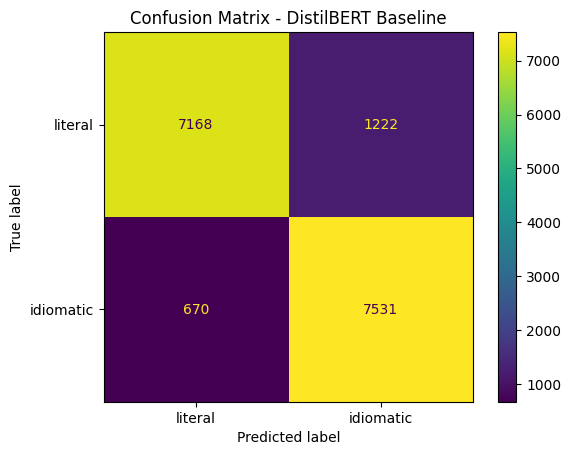

In [29]:
# ============================================================
# [2.12] Confusion matrix
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
predictions = trainer.predict(test_ds)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["literal", "idiomatic"])
disp.plot()

plt.title("Confusion Matrix - DistilBERT Baseline")
plt.show()

### Confusion Matrix Analysis

|                | Predicted Literal | Predicted Idiomatic |
|----------------|------------------|--------------------|
| **True Literal**   | 7168             | 1222               |
| **True Idiomatic** | 670              | 7531               |

### Observations

- The model correctly classifies:
  - **7168 literal examples**
  - **7531 idiomatic examples**

- **False Positives (Literal → Idiomatic):**
  - 1222 cases
  - This explains the slightly lower precision

- **False Negatives (Idiomatic → Literal):**
  - 670 cases
  - Fewer than false positives → consistent with high recall

### Interpretation

- The model is slightly **biased toward predicting idiomatic usage**, which leads to:
  - Higher recall
  - Lower precision

- This behavior suggests that:
  - The model prefers capturing semantic signals of idiomaticity
  - But sometimes overgeneralizes when literal meaning is subtle

### Key Insight

DistilBERT is strong at identifying idiomatic expressions but struggles with:
- subtle literal usages
- borderline semantic cases (even after filtering)

This motivates using a stronger contextual model to improve precision.

## [2.13] Detailed Classification Report

We provide per-class performance metrics to better understand model behavior across classes.

In [30]:
# ============================================================
# [2.13] Classification report
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=["literal", "idiomatic"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df.round(4))

,precision,recall,f1-score,support
literal,0.9145,0.8544,0.8834,8390.000
idiomatic,0.8604,0.9183,0.8884,8201.000
accuracy,0.8860,0.8860,0.8860,0.886
macro avg,0.8875,0.8863,0.8859,16591.000
weighted avg,0.8878,0.8860,0.8859,16591.000


### Classification Report Analysis

- **Literal class**
  - Precision: 0.9145 (high → few false positives)
  - Recall: 0.8544 (lower → some literal missed)

- **Idiomatic class**
  - Precision: 0.8604
  - Recall: 0.9183 (very high → captures most idioms)

### Observations

- The model is slightly **better at detecting idiomatic usage than literal**
- Higher recall for idiomatic confirms earlier confusion matrix findings
- Literal class has higher precision but lower recall

### Conclusion

The model shows:
- Strong semantic understanding
- Slight bias toward idiomatic predictions

This reinforces the need for a stronger model to improve balance between precision and recall.

## [2.14] Qualitative Demo (Baseline Model)

We test the model on a few examples to observe predictions and confidence.

This helps illustrate:
- correct predictions
- failure cases
- model behavior in real scenarios

In [33]:
# [2.14] Demo predictions (baseline)
# ==================================

import torch

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predict_text(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move inputs to same device as model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    pred = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred].item()

    label = "idiomatic" if pred == 1 else "literal"

    return label, confidence


# Example sentences
examples = [
    "He finally kicked the bucket after years of illness.",
    "He kicked the bucket across the yard.",
    "She spilled the beans about the surprise party.",
    "She accidentally spilled the beans on the floor."
]

# Run predictions
for text in examples:
    label, conf = predict_text(text)
    print(f"Text: {text}")
    print(f"Prediction: {label} | Confidence: {conf:.3f}")
    print("-" * 60)

Text: He finally kicked the bucket after years of illness.
Prediction: idiomatic | Confidence: 0.998
------------------------------------------------------------
Text: He kicked the bucket across the yard.
Prediction: literal | Confidence: 0.994
------------------------------------------------------------
Text: She spilled the beans about the surprise party.
Prediction: idiomatic | Confidence: 0.998
------------------------------------------------------------
Text: She accidentally spilled the beans on the floor.
Prediction: literal | Confidence: 0.996
------------------------------------------------------------


### Qualitative Analysis (Baseline Model)

The model correctly distinguishes between idiomatic and literal usage in all tested examples.

#### Observations

- The model assigns **very high confidence** (>0.99) to its predictions
- It successfully differentiates:
  - idiomatic meaning ("kicked the bucket" → died)
  - literal meaning ("kicked the bucket across the yard")

- Similar behavior is observed for:
  - "spill the beans" (idiomatic vs literal)

#### Key Insight

The model demonstrates strong contextual understanding:
- It does not rely only on the presence of an idiom
- It uses sentence context to determine meaning

# 3. RoBERTa Model

- **Model:** `roberta-base`

RoBERTa improves over BERT by:
- better training strategy
- more robust contextual representations

This model is expected to improve:
- precision
- overall F1-score

In [34]:
# [3.1] Load RoBERTa tokenizer
# ============================

MODEL_NAME = "roberta-base"

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [35]:
# [3.2] Tokenization for RoBERTa
# ==============================

def tokenize_function(example):
    return tokenizer(
        example["example"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Recreate datasets (clean way)
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

# Remove text + index
cols_to_remove = [col for col in train_ds.column_names if col not in ["input_ids", "attention_mask", "label"]]

train_ds = train_ds.remove_columns(cols_to_remove)
val_ds   = val_ds.remove_columns(cols_to_remove)
test_ds  = test_ds.remove_columns(cols_to_remove)

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")

train_ds

Map: 100%|█████████████████████████████████████████████████████████████| 16591/16591 [00:01<00:00, 10751.80 examples/s]


Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 133082
})

In [36]:
# [3.3] Load RoBERTa model
# ========================

from transformers import AutoModelForSequenceClassification

id2label = {
    0: "literal",
    1: "idiomatic"
}

label2id = {
    "literal": 0,
    "idiomatic": 1
}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded:", MODEL_NAME)
print("Number of labels:", model.num_labels)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: roberta-base
Number of labels: 2


In [37]:
# [3.4] RoBERTa training configuration
# ====================================

from transformers import TrainingArguments

roberta_output_dir = str(MODEL_DIR / "roberta_best")

training_args = TrainingArguments(
    output_dir=roberta_output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    save_total_limit=2,
    report_to="none",
    seed=SEED
)

print("Training arguments created successfully.")
print("Output directory:", roberta_output_dir)

Training arguments created successfully.
Output directory: task1_artifacts\models\roberta_best


## [3.5] Trainer Setup for RoBERTa

Connect the RoBERTa model, tokenized datasets, training arguments, and evaluation metrics into a Hugging Face `Trainer`.

In [38]:
# [3.5] Create RoBERTa trainer
# ============================

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print("RoBERTa trainer created successfully.")

RoBERTa trainer created successfully.


## [3.6] Train the RoBERTa Model

We now fine-tune RoBERTa on the training split and evaluate it on the validation split after each epoch.

The best checkpoint will be selected automatically using validation F1-score.

In [39]:
# ============================================================
# [3.6] Train RoBERTa model
# ============================================================

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.669700,0.694647,0.490907,0.490907,1.000000,0.658535
2,0.694000,0.692994,0.509093,0.000000,0.000000,0.000000


TrainOutput(global_step=33272, training_loss=0.6818310241625841, metrics={'train_runtime': 5672.5398, 'train_samples_per_second': 46.921, 'train_steps_per_second': 5.865, 'total_flos': 1.750767273470976e+16, 'train_loss': 0.6818310241625841, 'epoch': 2.0})

In [40]:
# ============================================================
# [3.7] Inspect dataset columns (debug)
# ============================================================

print("Train columns:", train_ds.column_names)
print("Validation columns:", val_ds.column_names)

Train columns: ['label', 'input_ids', 'attention_mask']
Validation columns: ['label', 'input_ids', 'attention_mask']


## [3.7] Debug the RoBERTa Run

The validation metrics suggest that the model collapsed to a single-class prediction.

Before changing the training setup, we first confirm this behavior by checking the prediction distribution on the validation set.

In [41]:
# ============================================================
# [3.7] Check prediction distribution on validation set
# ============================================================

val_predictions = trainer.predict(val_ds)

y_val_true = val_predictions.label_ids
y_val_pred = val_predictions.predictions.argmax(axis=1)

print("True label distribution:")
print(pd.Series(y_val_true).value_counts().sort_index())

print("\nPredicted label distribution:")
print(pd.Series(y_val_pred).value_counts().sort_index())

True label distribution:
0    8454
1    8152
Name: count, dtype: int64

Predicted label distribution:
1    16606
Name: count, dtype: int64


## [3.8] Fix the RoBERTa Training Setup

The previous RoBERTa run collapsed into a single-class predictor.

To stabilize training, we restart with a safer configuration:
- lower learning rate
- warmup
- fresh model initialization
- same leakage-free splits

This is a standard correction when fine-tuning large transformer models.

In [42]:
# ============================================================
# [3.8] Reload a fresh RoBERTa model
# ============================================================

from transformers import AutoModelForSequenceClassification

MODEL_NAME = "roberta-base"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

print("Fresh model loaded:", MODEL_NAME)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fresh model loaded: roberta-base


In [43]:
# ============================================================
# [3.9] Stable training arguments for RoBERTa
# ============================================================

from transformers import TrainingArguments

roberta_output_dir = str(MODEL_DIR / "roberta_best_stable")

training_args = TrainingArguments(
    output_dir=roberta_output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=2,
    report_to="none",
    seed=SEED
)

print("Stable training arguments created successfully.")
print("Output directory:", roberta_output_dir)

Stable training arguments created successfully.
Output directory: task1_artifacts\models\roberta_best_stable


In [44]:
# ============================================================
# [3.10] Recreate trainer for stable RoBERTa run
# ============================================================

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print("Stable RoBERTa trainer created successfully.")

Stable RoBERTa trainer created successfully.


In [ ]:
# ============================================================
# [3.11] Train stable RoBERTa model
# ============================================================

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.358200,0.329280,0.894074,0.902836,0.878803,0.890657
